In [ ]:
import os
import cv2z
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfTransformer
from scipy.spatial.distance import cdist
import torch
import torchvision.transforms as transforms
from torchvision.models import resnet50, ResNet50_Weights
from PIL import Image
import faiss
import time


!pip install faiss-gpu -q

In [ ]:
os.environ['KAGGLE_USERNAME'] = "your_kaggle_username"
os.environ['KAGGLE_KEY'] = "your_kaggle_token"

print("downloading dataset")

!kaggle datasets download -d imbikramsaha/caltech-101

print("download is done")

!mkdir -p /content/caltech-101
!unzip -q caltech-101.zip -d /content/caltech-101


if os.path.exists("caltech-101.zip"):
    os.remove("caltech-101.zip")

📊 تعداد کل تصاویر لود شده: 8677
🏷️ تعداد دسته‌بندی‌ها (کلاس‌ها): 101
🔍 در حال استخراج ویژگی‌های SIFT از تمام تصاویر...
✅ استخراج ویژگی برای 8677 تصویر با موفقیت انجام شد.
🎨 در حال خوشه‌بندی توصیف‌گرها (K-Means Clustering)...
✅ کتابچه لغات بصری ساخته شد.
⚖️ در حال محاسبه هیستوگرام تصاویر و اعمال TF-IDF...
✅ دیتابیس برداری آماده جستجو است.

🔍 تست بازیابی برای تصویر: /content/caltech-101/caltech-101/brain/image_0032.jpg


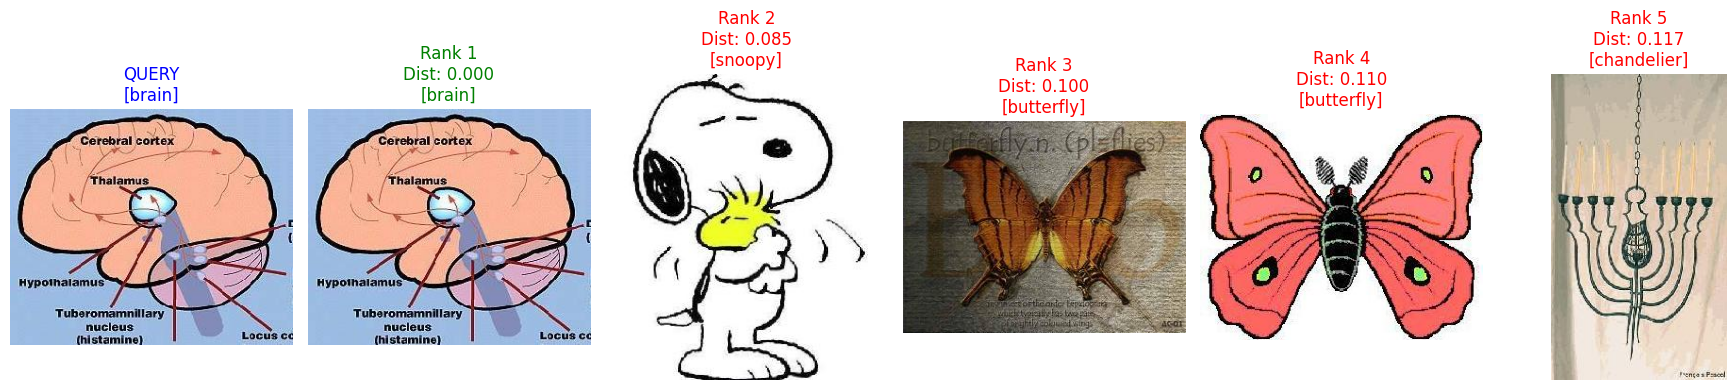

In [ ]:
DATASET_DIR = "/content/caltech-101/101_ObjectCategories"

if not os.path.exists(DATASET_DIR):
    DATASET_DIR = "/content/caltech-101"

image_paths = []
labels = []

for root, dirs, files in os.walk(DATASET_DIR):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            if "BACKGROUND" in root.upper():
                continue
            full_path = os.path.join(root, file)
            image_paths.append(full_path)
            labels.append(os.path.basename(root))

print(f"total amount of images {len(image_paths)}")
print(f"amount of classes {len(set(labels))}")


sift = cv2.SIFT_create()
descriptors_list = []
valid_image_paths = []
valid_labels = []


for path, label in zip(image_paths, labels):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        continue
    kp, des = sift.detectAndCompute(img, None)


    if des is not None and len(des) >= 15:
        descriptors_list.append(des)
        valid_image_paths.append(path)
        valid_labels.append(label)

all_descriptors = np.vstack(descriptors_list)


if len(all_descriptors) > 150000:
    indices = np.random.choice(len(all_descriptors), 150000, replace=False)
    sampled_descriptors = all_descriptors[indices]
else:
    sampled_descriptors = all_descriptors

NUM_WORDS = 100
kmeans = KMeans(n_clusters=NUM_WORDS, random_state=42, n_init=5)
kmeans.fit(sampled_descriptors)

def get_bovw_histogram(descriptors):
    words = kmeans.predict(descriptors)
    hist, _ = np.histogram(words, bins=range(NUM_WORDS + 1))
    return hist

raw_histograms = np.array([get_bovw_histogram(des) for des in descriptors_list])

tfidf = TfidfTransformer(norm='l2')
tfidf_histograms = tfidf.fit_transform(raw_histograms).toarray()

def search_similar_images(query_path, top_k=5):
    query_img = cv2.imread(query_path, cv2.IMREAD_GRAYSCALE)
    _, query_des = sift.detectAndCompute(query_img, None)

    if query_des is None:
        print(f"No valid descriptors found in the query image: {query_path}")
        return


    raw_query_hist = get_bovw_histogram(query_des).reshape(1, -1)
    query_tfidf = tfidf.transform(raw_query_hist).toarray()


    distances = cdist(query_tfidf, tfidf_histograms, metric='cosine')[0]
    top_indices = np.argsort(distances)[:top_k]

    fig, axes = plt.subplots(1, top_k + 1, figsize=(18, 4))

    q_rgb = cv2.cvtColor(cv2.imread(query_path), cv2.COLOR_BGR2RGB)
    axes[0].imshow(q_rgb)
    axes[0].set_title(f"QUERY\n[{os.path.basename(os.path.dirname(query_path))}]", color='blue')
    axes[0].axis('off')

    for i, idx in enumerate(top_indices):
        match_rgb = cv2.cvtColor(cv2.imread(valid_image_paths[idx]), cv2.COLOR_BGR2RGB)
        axes[i+1].imshow(match_rgb)


        is_correct = valid_labels[idx] == os.path.basename(os.path.dirname(query_path))
        title_color = 'green' if is_correct else 'red'

        axes[i+1].set_title(f"Rank {i+1}\nDist: {distances[idx]:.3f}\n[{valid_labels[idx]}]", color=title_color)
        axes[i+1].axis('off')

    plt.tight_layout()
    plt.show()


random_idx = np.random.randint(0, len(valid_image_paths))
test_image_path = valid_image_paths[random_idx]
search_similar_images(test_image_path, top_k=5)

Using device: cuda
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 212MB/s]


Extracting Deep Features for 8677 images...
Deep Feature Extraction Completed successfully!


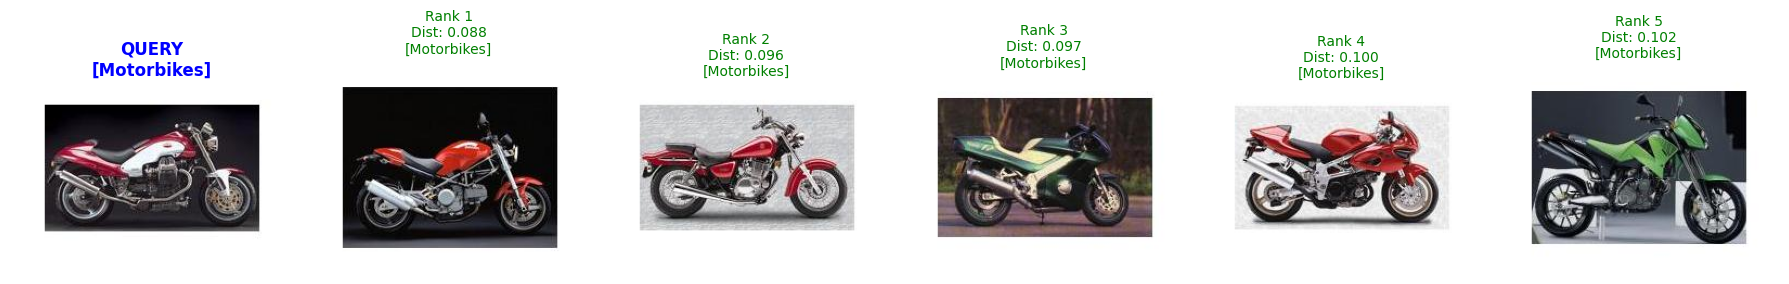

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

weights = ResNet50_Weights.DEFAULT
model = resnet50(weights=weights)
model = torch.nn.Sequential(*list(model.children())[:-1])
model = model.to(device)
model.eval()


transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


DATASET_DIR = "/content/caltech-101/101_ObjectCategories"
if not os.path.exists(DATASET_DIR):
    DATASET_DIR = "/content/caltech-101"

valid_paths, valid_labels = [], []
for root, dirs, files in os.walk(DATASET_DIR):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')) and "BACKGROUND" not in root.upper():
            valid_paths.append(os.path.join(root, file))
            valid_labels.append(os.path.basename(root))

print(f"Extracting Deep Features for {len(valid_paths)} images...")

embeddings = []
with torch.no_grad():
    for path in valid_paths:
        try:
            img = Image.open(path).convert('RGB')
            tensor_img = transform(img).unsqueeze(0).to(device)
            feature_vec = model(tensor_img).squeeze().cpu().numpy()
            feature_vec = feature_vec / np.linalg.norm(feature_vec)
            embeddings.append(feature_vec)
        except Exception as e:
            continue

embeddings = np.array(embeddings)
print("Deep Feature Extraction Completed successfully!")

def search_deep_cbir(query_idx, top_k=5):
    query_path = valid_paths[query_idx]
    query_label = valid_labels[query_idx]
    query_vec = embeddings[query_idx].reshape(1, -1)

    distances = cdist(query_vec, embeddings, metric='cosine')[0]

    top_indices = np.argsort(distances)[1:top_k+1]

    fig, axes = plt.subplots(1, top_k + 1, figsize=(18, 4))

    q_img = Image.open(query_path)
    axes[0].imshow(q_img)
    axes[0].set_title(f"QUERY\n[{query_label}]", color='blue', fontweight='bold')
    axes[0].axis('off')

    for i, idx in enumerate(top_indices):
        match_img = Image.open(valid_paths[idx])
        axes[i+1].imshow(match_img)

        is_correct = (valid_labels[idx] == query_label)
        title_color = 'green' if is_correct else 'red'

        axes[i+1].set_title(f"Rank {i+1}\nDist: {distances[idx]:.3f}\n[{valid_labels[idx]}]",
                            color=title_color, fontsize=10)
        axes[i+1].axis('off')

    plt.tight_layout()
    plt.show()

random_idx = np.random.randint(0, len(valid_paths))
search_deep_cbir(random_idx, top_k=5)

In [ ]:
def evaluate_deep_system(top_k=5, sample_size=300):
    precisions = []
    ap_list = []

    indices = np.random.choice(len(valid_paths), min(sample_size, len(valid_paths)), replace=False)

    for idx in indices:
        query_vec = embeddings[idx].reshape(1, -1)
        query_label = valid_labels[idx]

        distances = cdist(query_vec, embeddings, metric='cosine')[0]
        sorted_indices = np.argsort(distances)[1:top_k+1]

        retrieved_labels = [valid_labels[i] for i in sorted_indices]
        matches = [1 if l == query_label else 0 for l in retrieved_labels]

        precision_at_k = sum(matches) / top_k
        precisions.append(precision_at_k)

        score = 0.0
        hits = 0.0
        for rank, match in enumerate(matches):
            if match == 1:
                hits += 1.0
                score += hits / (rank + 1)
        ap_list.append(score / top_k if hits > 0 else 0)

    print(f"Mean Precision@{top_k}: {np.mean(precisions) * 100:.2f}%")
    print(f"Mean Average Precision (mAP): {np.mean(ap_list) * 100:.2f}%")

evaluate_deep_system(top_k=5, sample_size=300)

Mean Precision@5: 88.33%
Mean Average Precision (mAP): 85.43%


✅ تعداد 8677 بردار با موفقیت وارد ایندکس FAISS شدند.


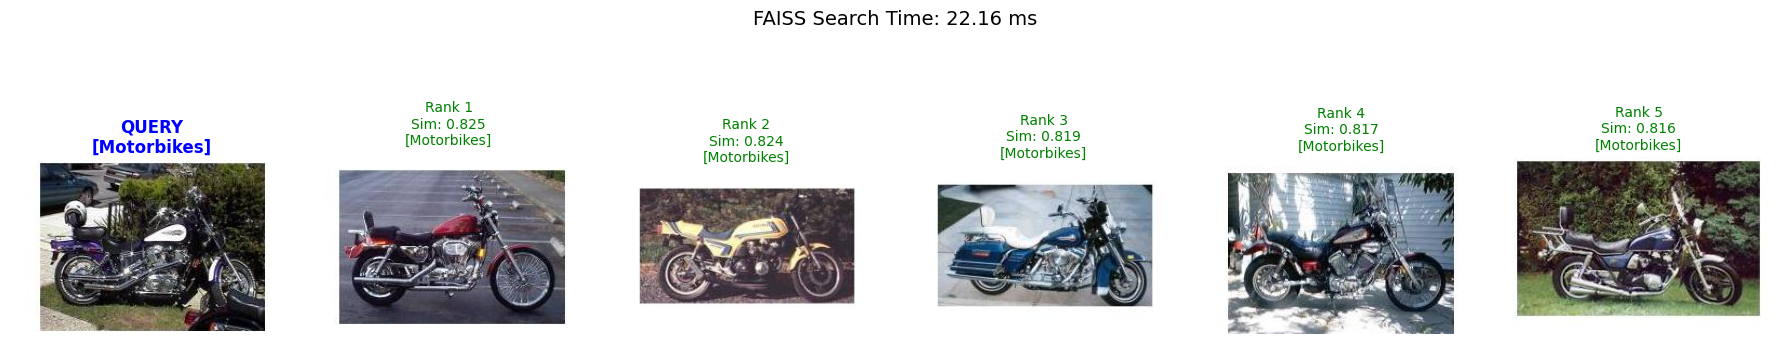

In [ ]:
embedding_matrix = np.array(embeddings).astype('float32')
faiss.normalize_L2(embedding_matrix)

dimension = embedding_matrix.shape[1]


res = faiss.StandardGpuResources()
cpu_index = faiss.IndexFlatIP(dimension)


gpu_index = faiss.index_cpu_to_gpu(res, 0, cpu_index)


gpu_index.add(embedding_matrix)
def search_faiss_cbir(query_idx, top_k=5):
    query_vec = embedding_matrix[query_idx:query_idx+1]
    query_label = valid_labels[query_idx]
    start_time = time.time()
    similarities, indices = gpu_index.search(query_vec, top_k + 1)

    elapsed_time = (time.time() - start_time) * 1000

    top_indices = indices[0][1:]
    top_sims = similarities[0][1:]
    fig, axes = plt.subplots(1, top_k + 1, figsize=(18, 4))

    q_img = Image.open(valid_paths[query_idx])
    axes[0].imshow(q_img)
    axes[0].set_title(f"QUERY\n[{query_label}]", color='blue', fontweight='bold')
    axes[0].axis('off')

    for i, (idx, sim) in enumerate(zip(top_indices, top_sims)):
        match_img = Image.open(valid_paths[idx])
        axes[i+1].imshow(match_img)

        is_correct = (valid_labels[idx] == query_label)
        title_color = 'green' if is_correct else 'red'

        axes[i+1].set_title(f"Rank {i+1}\nSim: {sim:.3f}\n[{valid_labels[idx]}]",
                            color=title_color, fontsize=10)
        axes[i+1].axis('off')

    plt.suptitle(f"FAISS Search Time: {elapsed_time:.2f} ms", fontsize=14, y=1.05)
    plt.tight_layout()
    plt.show()
test_idx = np.random.randint(0, len(valid_paths))
search_faiss_cbir(test_idx, top_k=5)